In [1]:
import inspect
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
df = pd.read_csv('retail_user_behavior_100k.csv')
df

,session_id,user_id,timestamp_utc,event_index,user_action,product_id,category,brand,price,channel,device_type,region,traffic_source,time_spent_sec,session_length,interaction_count,is_conversion,drop_off_flag
0,S0000001,U000372,2026-01-08T02:34:40Z,1,view,P1481,Electronics,Samsung,316.55,mobile,desktop,JP,organic,25,4,1,0,0
1,S0000001,U000372,2026-01-08T02:35:20Z,2,wishlist,P1481,Electronics,Samsung,316.55,mobile,desktop,JP,organic,28,4,2,0,0
2,S0000001,U000372,2026-01-08T02:35:43Z,3,view,P1481,Electronics,Samsung,316.55,mobile,desktop,JP,organic,5,4,3,0,0
3,S0000001,U000372,2026-01-08T02:36:13Z,4,drop,P1481,Electronics,Samsung,316.55,mobile,desktop,JP,organic,16,4,4,0,1
4,S0000002,U004812,2026-01-29T11:07:27Z,1,view,P1836,Groceries,OrganicCo,212.37,mobile,tablet,UK,direct,15,4,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108579,S0018000,U002836,2026-02-20T14:20:30Z,3,view,P1821,Groceries,DailyFresh,402.41,app,android,DE,referral,24,7,3,0,0
108580,S0018000,U002836,2026-02-20T14:21:15Z,4,click,P1821,Groceries,DailyFresh,402.41,app,android,DE,referral,26,7,4,0,0
108581,S0018000,U002836,2026-02-20T14:21:52Z,5,add_to_cart,P1821,Groceries,DailyFresh,402.41,app,android,DE,referral,20,7,5,0,0
108582,S0018000,U002836,2026-02-20T14:22:24Z,6,click,P1821,Groceries,DailyFresh,402.41,app,android,DE,referral,17,7,6,0,0


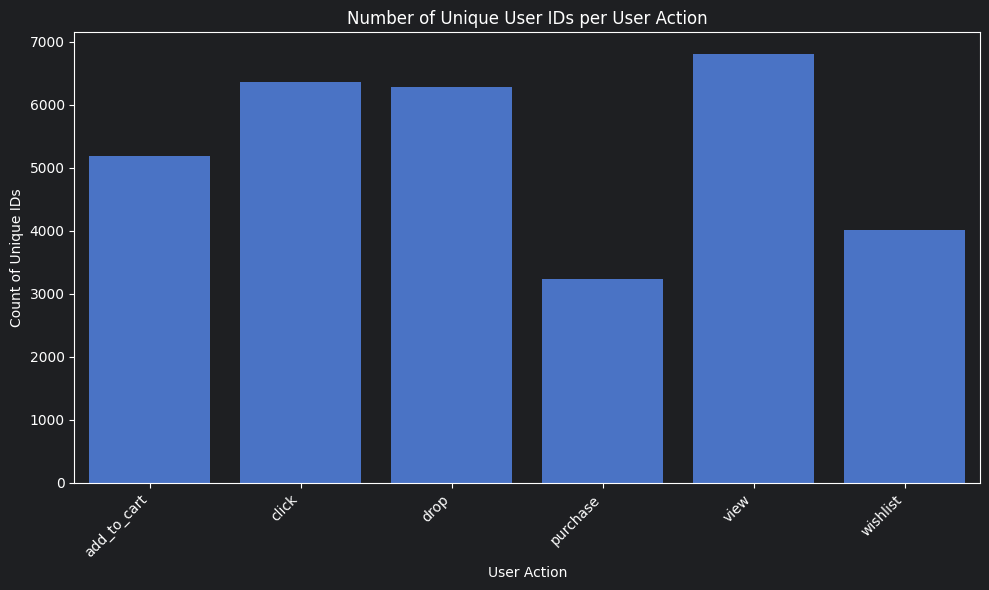

In [3]:
# plot a line chart of the number of unique IDs in each class with the user_action on the X-axis and the count on the Y-axis
unique_counts = df.groupby('user_action')['user_id'].nunique().reset_index()
unique_counts.columns = ['user_action', 'unique_count']

plt.figure(figsize=(10, 6))
sns.barplot(data=unique_counts, x='user_action', y='unique_count')
plt.xlabel('User Action')
plt.ylabel('Count of Unique IDs')
plt.title('Number of Unique User IDs per User Action')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [4]:
"""
Create a pivot table as a new dataframe from df. The pivot rows will be session_id, user_id, product_id, category,brand,price,channel,device_type,region,trafiic_source. The pivot columns will be `user_action` and the values will be the count of `user_action` category. Fill the missing values with 0.
"""
pivot_df = df.pivot_table(index=['session_id', 'user_id', 'product_id', 'category', 'brand', 'price', 'channel', 'device_type', 'region', 'traffic_source'],
                          columns='user_action',
                          values='event_index',
                          aggfunc='count',
                          fill_value=0)
pivot_df.reset_index(inplace=True)
pivot_df

user_action,session_id,user_id,product_id,category,brand,price,channel,device_type,region,traffic_source,add_to_cart,click,drop,purchase,view,wishlist
0,S0000001,U000372,P1481,Electronics,Samsung,316.55,mobile,desktop,JP,organic,0,0,1,0,2,1
1,S0000002,U004812,P1836,Groceries,OrganicCo,212.37,mobile,tablet,UK,direct,1,0,1,0,2,0
2,S0000003,U001935,P1816,Groceries,FreshFarm,261.82,web,android,AU,organic,3,1,0,1,1,0
3,S0000004,U001996,P1303,Accessories,Coach,272.61,app,desktop,IN,affiliate,0,0,1,0,0,0
4,S0000004,U001996,P1478,Electronics,Samsung,279.16,app,desktop,IN,affiliate,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40737,S0017999,U003712,P1931,Home,Wayfair,73.98,app,tablet,FR,organic,0,0,0,0,1,0
40738,S0017999,U003712,P2092,Sports,Decathlon,326.58,app,tablet,FR,organic,0,0,0,0,0,1
40739,S0017999,U003712,P2100,Sports,Spalding,178.31,app,tablet,FR,organic,0,2,0,0,3,0
40740,S0017999,U003712,P2192,Sports,Wilson,293.17,app,tablet,FR,organic,0,0,1,0,0,0


In [5]:
grouped_df = (
    df.groupby(
        [
            'session_id', 'user_id', 'product_id', 'category', 'brand', 'price',
            'channel', 'device_type', 'region', 'traffic_source'
        ],
        as_index=False
    ).agg(
        is_conversion=('is_conversion', 'sum'),
        drop_off_flag=('drop_off_flag', 'sum'),
        time_spent_sec=('time_spent_sec', 'sum'),
        session_length=('session_length', 'mean')
    )
)

grouped_df

,session_id,user_id,product_id,category,brand,price,channel,device_type,region,traffic_source,is_conversion,drop_off_flag,time_spent_sec,session_length
0,S0000001,U000372,P1481,Electronics,Samsung,316.55,mobile,desktop,JP,organic,0,1,74,4.0
1,S0000002,U004812,P1836,Groceries,OrganicCo,212.37,mobile,tablet,UK,direct,0,1,60,4.0
2,S0000003,U001935,P1816,Groceries,FreshFarm,261.82,web,android,AU,organic,1,0,122,6.0
3,S0000004,U001996,P1303,Accessories,Coach,272.61,app,desktop,IN,affiliate,0,1,11,3.0
4,S0000004,U001996,P1478,Electronics,Samsung,279.16,app,desktop,IN,affiliate,0,0,32,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40737,S0017999,U003712,P1931,Home,Wayfair,73.98,app,tablet,FR,organic,0,0,19,8.0
40738,S0017999,U003712,P2092,Sports,Decathlon,326.58,app,tablet,FR,organic,0,0,18,8.0
40739,S0017999,U003712,P2100,Sports,Spalding,178.31,app,tablet,FR,organic,0,0,77,8.0
40740,S0017999,U003712,P2192,Sports,Wilson,293.17,app,tablet,FR,organic,0,1,33,8.0


In [6]:
# Use `groupdf` if it exists; otherwise fall back to `grouped_df`
left_df = globals().get('groupdf', grouped_df)

join_keys = [
    'session_id', 'user_id', 'product_id', 'category', 'brand', 'price',
    'channel', 'device_type', 'region', 'traffic_source'
]

merged_df = left_df.merge(pivot_df, on=join_keys, how='inner')
merged_df

,session_id,user_id,product_id,category,brand,price,channel,device_type,region,traffic_source,is_conversion,drop_off_flag,time_spent_sec,session_length,add_to_cart,click,drop,purchase,view,wishlist
0,S0000001,U000372,P1481,Electronics,Samsung,316.55,mobile,desktop,JP,organic,0,1,74,4.0,0,0,1,0,2,1
1,S0000002,U004812,P1836,Groceries,OrganicCo,212.37,mobile,tablet,UK,direct,0,1,60,4.0,1,0,1,0,2,0
2,S0000003,U001935,P1816,Groceries,FreshFarm,261.82,web,android,AU,organic,1,0,122,6.0,3,1,0,1,1,0
3,S0000004,U001996,P1303,Accessories,Coach,272.61,app,desktop,IN,affiliate,0,1,11,3.0,0,0,1,0,0,0
4,S0000004,U001996,P1478,Electronics,Samsung,279.16,app,desktop,IN,affiliate,0,0,32,3.0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40737,S0017999,U003712,P1931,Home,Wayfair,73.98,app,tablet,FR,organic,0,0,19,8.0,0,0,0,0,1,0
40738,S0017999,U003712,P2092,Sports,Decathlon,326.58,app,tablet,FR,organic,0,0,18,8.0,0,0,0,0,0,1
40739,S0017999,U003712,P2100,Sports,Spalding,178.31,app,tablet,FR,organic,0,0,77,8.0,0,2,0,0,3,0
40740,S0017999,U003712,P2192,Sports,Wilson,293.17,app,tablet,FR,organic,0,1,33,8.0,0,0,1,0,0,0


In [7]:
merged_df = merged_df.drop(columns=['drop_off_flag', 'drop', 'purchase'])

In [8]:
from sklearn.model_selection import train_test_split

# Create a stratification key combining all specified columns
stratify_col = merged_df[['category', 'brand', 'channel', 'device_type', 'region', 'traffic_source']].astype(str).agg('_'.join, axis=1)

# Make stratification safe by grouping ultra-rare strata (count < 2) into one bucket
strata_counts = stratify_col.value_counts()
stratify_safe = stratify_col.where(stratify_col.map(strata_counts) >= 2, "__RARE__")

train_df, test_df = train_test_split(
    merged_df,
    test_size=0.3,
    random_state=42,
    stratify=stratify_safe
)

print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

Train size: 28519, Test size: 12223


In [9]:
cols_to_drop = ['session_id', 'user_id']

train_df = train_df.drop(columns=cols_to_drop, errors='ignore')
test_df = test_df.drop(columns=cols_to_drop, errors='ignore')

print("train_df columns:", train_df.columns.tolist())
print("test_df columns:", test_df.columns.tolist())

train_df columns: ['product_id', 'category', 'brand', 'price', 'channel', 'device_type', 'region', 'traffic_source', 'is_conversion', 'time_spent_sec', 'session_length', 'add_to_cart', 'click', 'view', 'wishlist']
test_df columns: ['product_id', 'category', 'brand', 'price', 'channel', 'device_type', 'region', 'traffic_source', 'is_conversion', 'time_spent_sec', 'session_length', 'add_to_cart', 'click', 'view', 'wishlist']


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Dependent and independent variables
target_col = "is_conversion"
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

# Column groups for preprocessing
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()

# ColumnTransformer for feature preparation
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

# Decision Tree pipeline (preprocessing + model)
dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

# Train and evaluate
dt_pipeline.fit(X_train, y_train)
y_pred = dt_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8722899451853063
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     10989
           1       0.34      0.28      0.30      1234

    accuracy                           0.87     12223
   macro avg       0.63      0.61      0.62     12223
weighted avg       0.86      0.87      0.87     12223



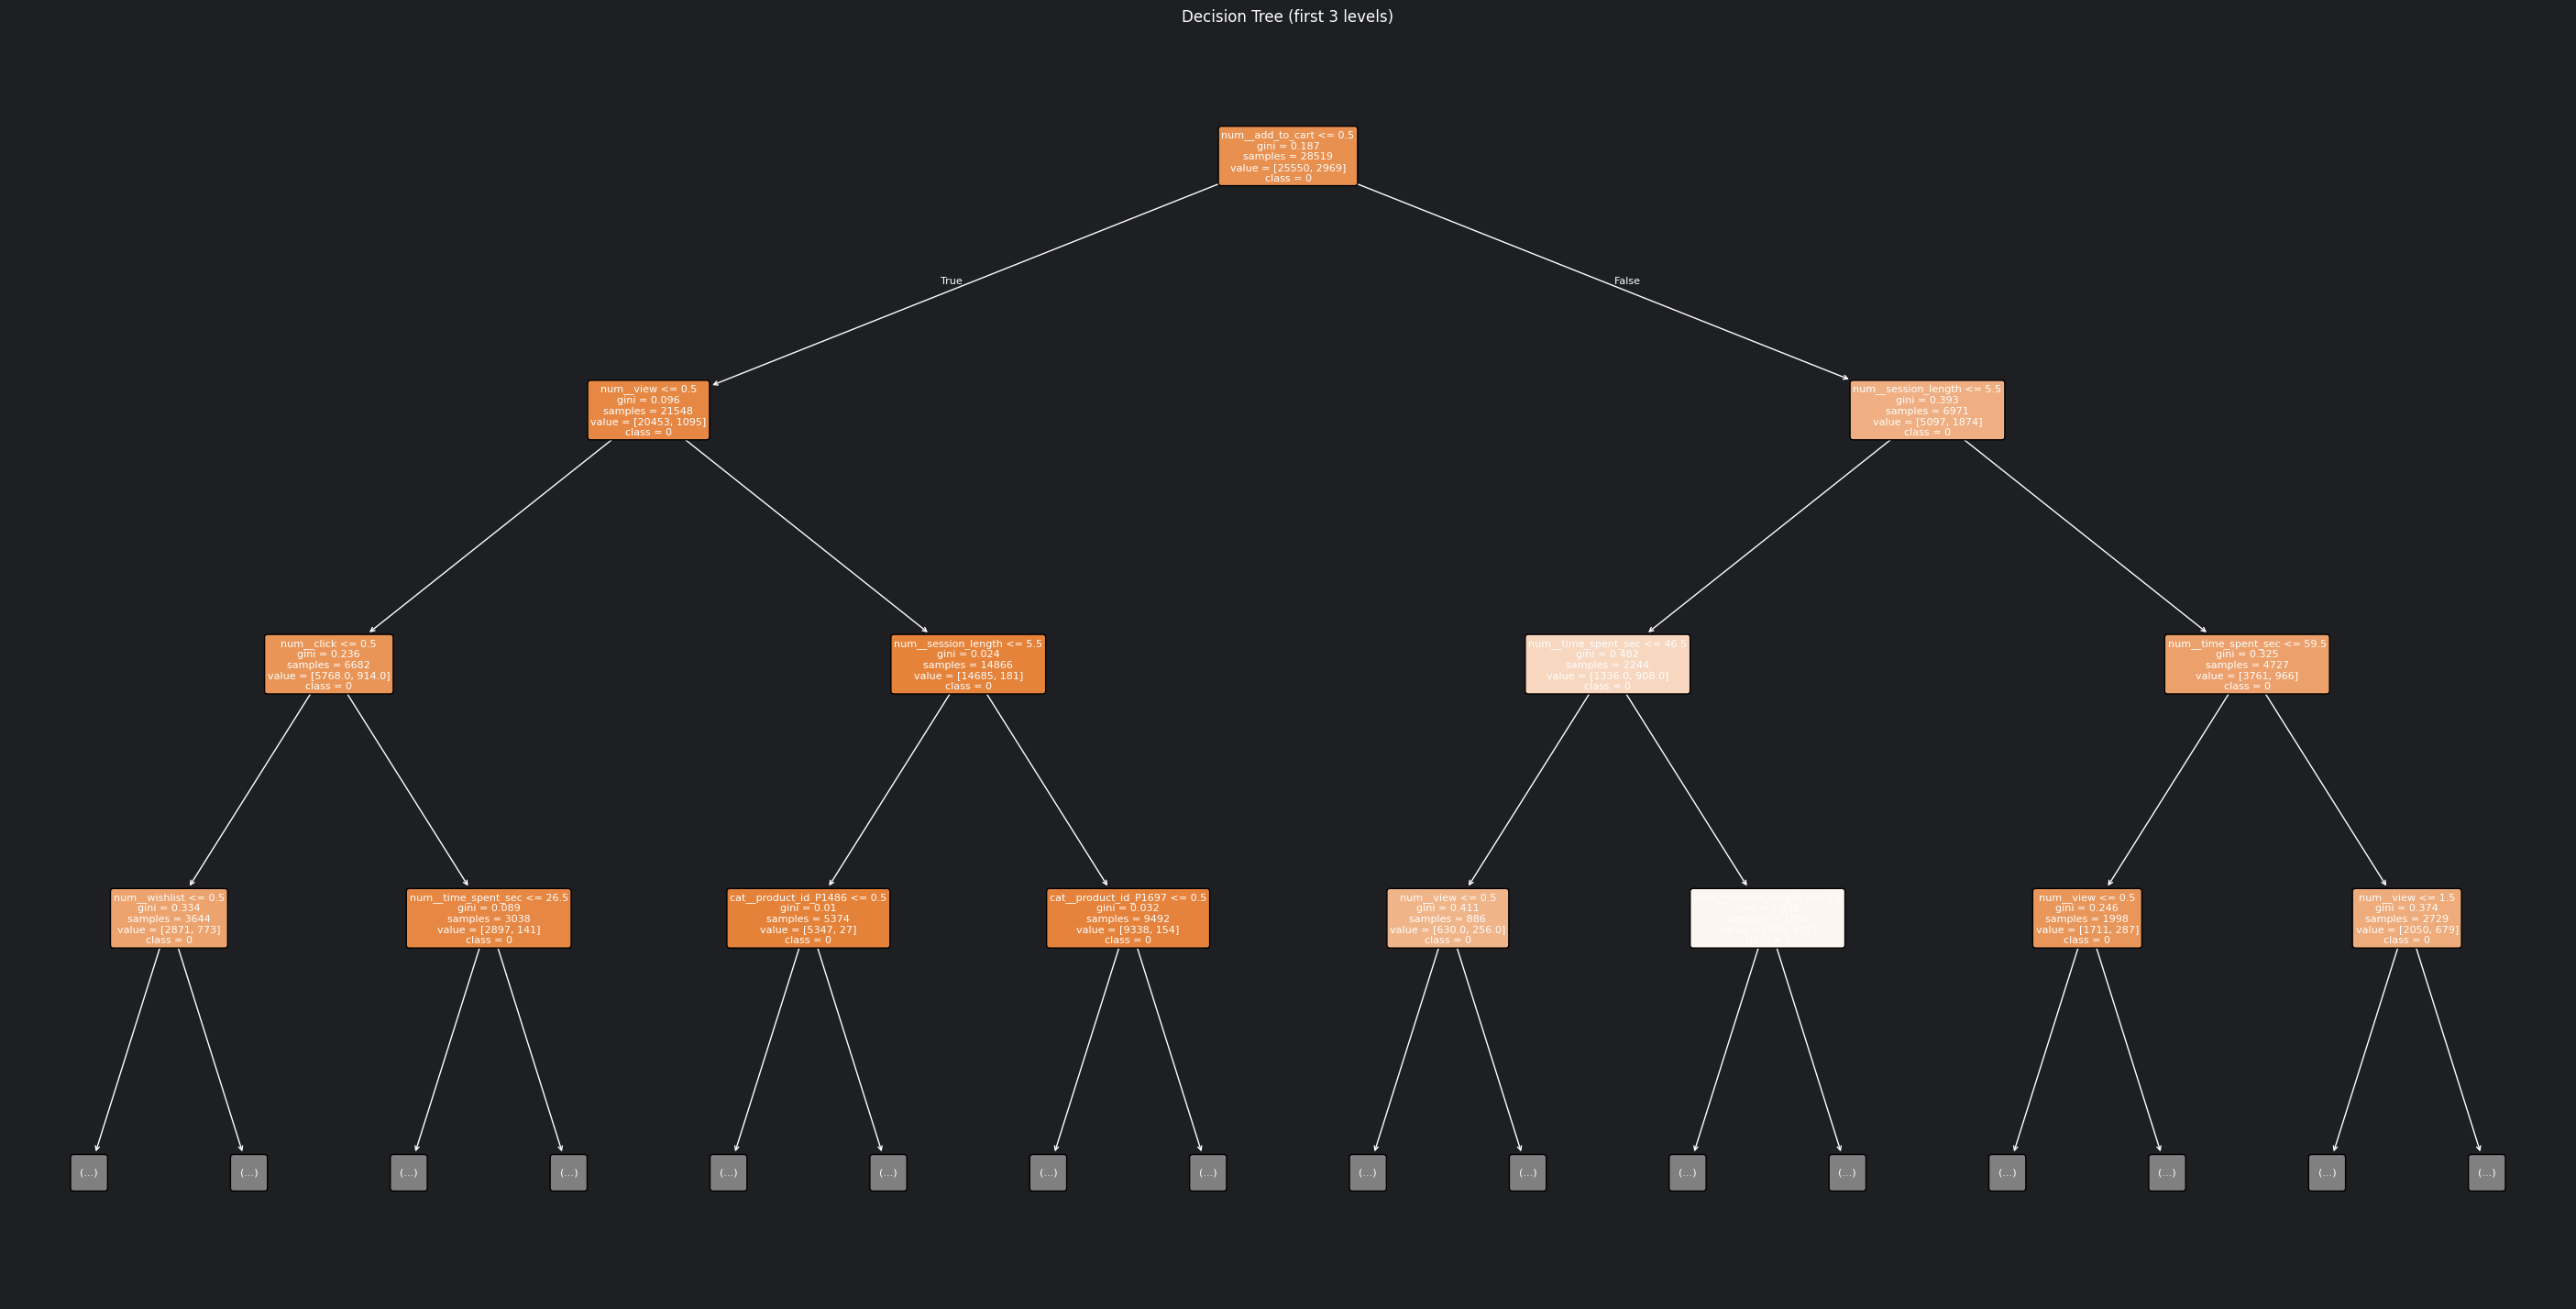

In [11]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Extract transformed feature names from the fitted preprocessor
feature_names = dt_pipeline.named_steps["preprocessor"].get_feature_names_out()
class_names = [str(c) for c in dt_pipeline.named_steps["model"].classes_]

# Plot only the top levels to keep the diagram readable
plt.figure(figsize=(36, 18))
plot_tree(
    dt_pipeline.named_steps["model"],
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
 )
plt.title("Decision Tree (first 3 levels)")
plt.show()

Decision Tree Accuracy: 0.8722899451853063
Random Forest Train Accuracy: 1.0
Random Forest Test Accuracy: 0.9001881698437372
Random Forest ROC-AUC: 0.8363382536802311
Random Forest OOB Score: 0.8989094989305375

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.90      1.00      0.95     10989
           1       0.57      0.05      0.09      1234

    accuracy                           0.90     12223
   macro avg       0.74      0.52      0.52     12223
weighted avg       0.87      0.90      0.86     12223



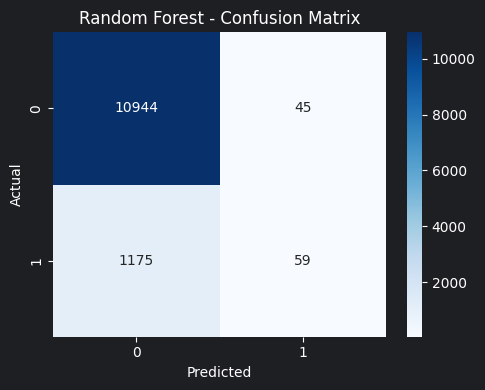

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score

# Fresh preprocessor (to avoid mutating existing dt_pipeline objects)
rf_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced",
            oob_score=True
        ))
    ]
)

# Train
rf_pipeline.fit(X_train, y_train)

# Predict
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]
y_train_pred_rf = rf_pipeline.predict(X_train)

# Metrics
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest Train Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Random Forest Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("Random Forest OOB Score:", rf_pipeline.named_steps["model"].oob_score_)
print("\nRandom Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

# Confusion matrix (monitoring)
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [13]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.pipeline import Pipeline

hgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            HistGradientBoostingClassifier(
                learning_rate=0.05, max_depth=6, max_iter=300, random_state=42
            ),
        ),
    ]
)

# HistGradientBoostingClassifier needs dense features (not sparse)
try:
    dense_ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
except TypeError:
    dense_ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse=False)

hgb_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", dense_ohe, categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

hgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", hgb_preprocessor),
        (
            "model",
            HistGradientBoostingClassifier(
                learning_rate=0.05, max_depth=6, max_iter=300, random_state=42
            ),
        ),
    ]
)

hgb_pipeline.fit(X_train, y_train)
y_pred_hgb = hgb_pipeline.predict(X_test)
y_proba_hgb = hgb_pipeline.predict_proba(X_test)[:, 1]

print("HistGB Accuracy:", accuracy_score(y_test, y_pred_hgb))
print("HistGB ROC-AUC:", roc_auc_score(y_test, y_proba_hgb))
print(classification_report(y_test, y_pred_hgb))

HistGB Accuracy: 0.9015789904278818
HistGB ROC-AUC: 0.8633788127305145
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     10989
           1       0.55      0.14      0.23      1234

    accuracy                           0.90     12223
   macro avg       0.73      0.56      0.59     12223
weighted avg       0.87      0.90      0.87     12223



In [14]:
# Compare model performance in a pandas DataFrame
model_reports = {
    "Decision Tree": classification_report(y_test, y_pred, output_dict=True, zero_division=0),
    "Random Forest": classification_report(y_test, y_pred_rf, output_dict=True, zero_division=0),
    "HistGradientBoosting": classification_report(y_test, y_pred_hgb, output_dict=True, zero_division=0),
}

model_comparison_df = pd.DataFrame(
    [
        {
            "Model": "Decision Tree",
            "Precision": model_reports["Decision Tree"]["weighted avg"]["precision"],
            "Recall": model_reports["Decision Tree"]["weighted avg"]["recall"],
            "F1-Score": model_reports["Decision Tree"]["weighted avg"]["f1-score"],
        },
        {
            "Model": "Random Forest",
            "Precision": model_reports["Random Forest"]["weighted avg"]["precision"],
            "Recall": model_reports["Random Forest"]["weighted avg"]["recall"],
            "F1-Score": model_reports["Random Forest"]["weighted avg"]["f1-score"],
        },
        {
            "Model": "HistGradientBoosting",
            "Precision": model_reports["HistGradientBoosting"]["weighted avg"]["precision"],
            "Recall": model_reports["HistGradientBoosting"]["weighted avg"]["recall"],
            "F1-Score": model_reports["HistGradientBoosting"]["weighted avg"]["f1-score"],
        },
    ]
)

model_comparison_df = model_comparison_df.round(4)
display(model_comparison_df)

,Model,Precision,Recall,F1-Score
0,Decision Tree,0.8615,0.8723,0.8665
1,Random Forest,0.8691,0.9002,0.8605
2,HistGradientBoosting,0.8745,0.9016,0.8746


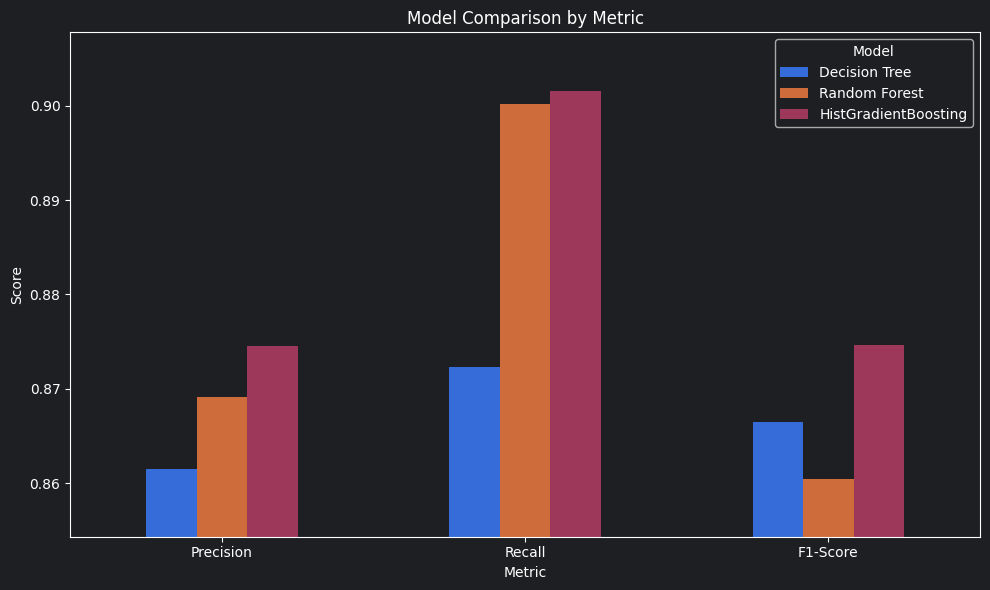

In [15]:
# Metrics on X-axis, models as grouped bars
plot_df = model_comparison_df.set_index("Model").T  # rows: metrics, cols: models

ax = plot_df.plot(
    kind="bar",
    figsize=(10, 6),
    rot=0
)

plt.title("Model Comparison by Metric")
plt.xlabel("Metric")
plt.ylabel("Score")

# Zoom Y-axis around actual values for better visual separation
y_min = plot_df.min().min()
y_max = plot_df.max().max()
padding = max((y_max - y_min) * 0.15, 0.005)
lower = max(0, y_min - padding)
upper = min(1, y_max + padding)
plt.ylim(lower, upper)

plt.legend(title="Model")
plt.tight_layout()
plt.show()

In [16]:
# Establishing the importance of individual features
# Run this after hgb_pipeline is already fitted
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# Use a metric aligned with your objective (class imbalance exists in your report)
perm = permutation_importance(
    hgb_pipeline,
    X_test,
    y_test,
    scoring="f1_weighted",   # or "accuracy", "roc_auc" if that is your main metric
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(importance_df.head(20))

,feature,importance_mean,importance_std
10,add_to_cart,0.019914,0.000947
8,time_spent_sec,0.011432,0.001434
9,session_length,0.010888,0.001494
12,view,0.002265,0.001362
1,category,0.000458,0.000251
5,device_type,0.000279,0.000343
7,traffic_source,0.000215,0.000145
2,brand,0.000185,0.000431
11,click,0.000177,0.000530
0,product_id,0.000142,0.000169


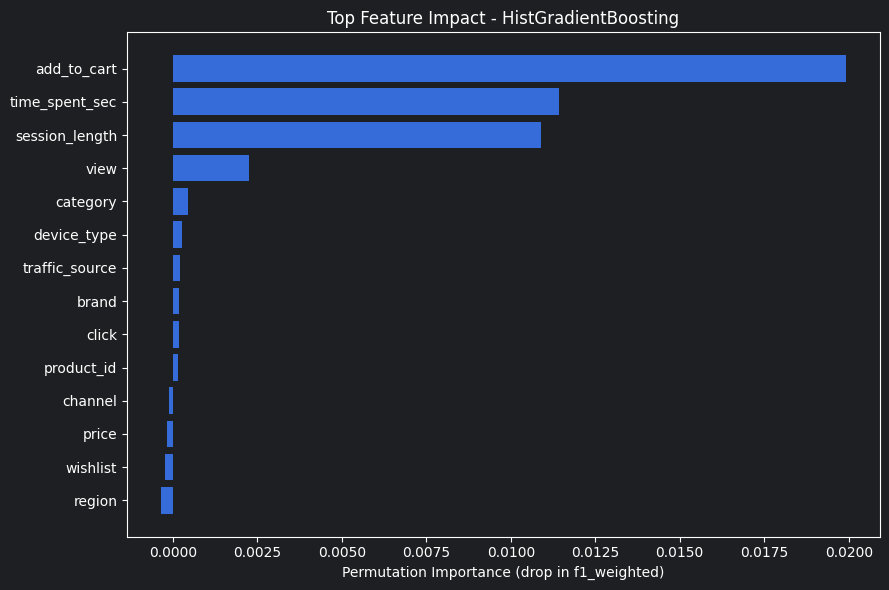

In [17]:
# Optional: quick chart of top features
top_n = 15
plot_df = importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(9, 6))
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.xlabel("Permutation Importance (drop in f1_weighted)")
plt.title("Top Feature Impact - HistGradientBoosting")
plt.tight_layout()
plt.show()

In [18]:
# Running SHAP to better understand the impact of the attributes on the
import shap
import numpy as np

# 1) Pull fitted objects from your existing pipeline
pre = hgb_pipeline.named_steps["preprocessor"]
model = hgb_pipeline.named_steps["model"]

# 2) Transform train/test using the same fitted preprocessor
X_train_t = pre.transform(X_train)
X_test_t = pre.transform(X_test)

# Ensure dense array (usually already dense with your dense_ohe)
if not isinstance(X_train_t, np.ndarray):
    X_train_t = X_train_t.toarray()
if not isinstance(X_test_t, np.ndarray):
    X_test_t = X_test_t.toarray()

# Feature names after OHE + passthrough nums
feature_names = pre.get_feature_names_out()

# Optional: DataFrame for cleaner plotting labels
X_test_t_df = pd.DataFrame(X_test_t, columns=feature_names)

# 3) Build SHAP explainer
# For tree-based sklearn models, shap.Explainer usually picks TreeExplainer automatically
explainer = shap.Explainer(model, X_train_t, feature_names=feature_names)

# 4) Compute SHAP values on test set
# (Use a sample if test set is large to speed up)
sample_n = min(5000, X_test_t_df.shape[0])
X_shap = X_test_t_df.sample(sample_n, random_state=42) if X_test_t_df.shape[0] > sample_n else X_test_t_df.copy()

shap_values = explainer(X_shap, check_additivity=False)

print("SHAP values shape:", shap_values.values.shape)
print("Base value:", shap_values.base_values[:3] if np.ndim(shap_values.base_values) else shap_values.base_values)

ModuleNotFoundError: No module named 'shap'

In [ ]:
shap.plots.bar(shap_values, max_display=20)
shap.plots.beeswarm(shap_values, max_display=20)
row_idx = 0
shap.plots.waterfall(shap_values[row_idx], max_display=15)
top_feature = shap_values.feature_names[np.argmax(np.abs(shap_values.values).mean(axis=0))]
shap.plots.scatter(shap_values[:, top_feature], color=shap_values)

In [ ]:
import re

# Inputs expected from earlier cells:
# - hgb_pipeline (fitted)
# - shap_values from explainer(X_shap)   # shape: [n_samples, n_transformed_features]
# - categorical_cols, numeric_cols (already in your notebook)

pre = hgb_pipeline.named_steps["preprocessor"]
transformed_feature_names = pre.get_feature_names_out()

# SHAP matrix (n_samples, n_transformed_features)
# For binary classification this is typically 2D for current SHAP API with sklearn trees
shap_matrix = shap_values.values
if shap_matrix.ndim != 2:
    raise ValueError(f"Expected 2D SHAP matrix, got shape {shap_matrix.shape}")


# ---- Helper: map transformed feature name -> original feature group ----
def to_original_feature(transformed_name: str) -> str:
    """
    Examples:
      cat__brand_Nike            -> brand
      cat__traffic_source_Email  -> traffic_source
      num__price                 -> price
      remainder__...             -> ...
    """
    if transformed_name.startswith("num__"):
        return transformed_name.replace("num__", "", 1)

    if transformed_name.startswith("cat__"):
        body = transformed_name.replace("cat__", "", 1)

        # Match against known categorical columns from longest to shortest
        # so names like traffic_source are matched before source-like fragments.
        for col in sorted(categorical_cols, key=len, reverse=True):
            if body == col or body.startswith(col + "_"):
                return col

        # Fallback: split at first underscore
        return body.split("_", 1)[0]

    # Generic fallback for unexpected prefixes
    return transformed_name.split("__", 1)[-1].split("_", 1)[0]


original_feature_map = [to_original_feature(f) for f in transformed_feature_names]

# ---- 1) Global stakeholder view: total absolute SHAP impact by original feature ----
abs_shap = np.abs(shap_matrix)  # absolute contribution magnitudes
global_abs_mean = abs_shap.mean(axis=0)  # per transformed column

agg_global_df = (
    pd.DataFrame({
        "transformed_feature": transformed_feature_names,
        "original_feature": original_feature_map,
        "mean_abs_shap": global_abs_mean
    })
    .groupby("original_feature", as_index=False)["mean_abs_shap"]
    .sum()
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(agg_global_df.head(20))

# Plot
top_n = 15
plot_df = agg_global_df.head(top_n).iloc[::-1]
plt.figure(figsize=(9, 6))
plt.barh(plot_df["original_feature"], plot_df["mean_abs_shap"])
plt.xlabel("Total mean(|SHAP|)")
plt.title("Global SHAP Impact Aggregated to Original Features")
plt.tight_layout()
plt.show()

# ---- 2) Optional: signed SHAP (net push direction) by original feature ----
# Useful to show whether a feature tends to push predictions up/down on average.
signed_mean = shap_matrix.mean(axis=0)

agg_signed_df = (
    pd.DataFrame({
        "transformed_feature": transformed_feature_names,
        "original_feature": original_feature_map,
        "mean_signed_shap": signed_mean
    })
    .groupby("original_feature", as_index=False)["mean_signed_shap"]
    .sum()
    .sort_values("mean_signed_shap", key=lambda s: s.abs(), ascending=False)
    .reset_index(drop=True)
)

display(agg_signed_df.head(20))

# ---- 3) Optional: per-row local explanation aggregated to original feature ----
# Choose one prediction row from the SHAP set
row_idx = 0
row_vals = shap_matrix[row_idx]

local_agg_df = (
    pd.DataFrame({
        "transformed_feature": transformed_feature_names,
        "original_feature": original_feature_map,
        "shap_value": row_vals
    })
    .groupby("original_feature", as_index=False)["shap_value"]
    .sum()
    .sort_values("shap_value", key=lambda s: s.abs(), ascending=False)
    .reset_index(drop=True)
)

display(local_agg_df.head(15))

In [ ]:
## Investigate click: Permutation vs SHAP
# 1) Get click's permutation importance from cell 17
click_perm_importance = importance_df[importance_df['feature'] == 'click']['importance_mean'].values
if len(click_perm_importance) == 0:
    print("'click' not found in importance_df. Check spelling.")
else:
    click_perm_importance = click_perm_importance[0]
    print(f"Permutation Importance (click): {click_perm_importance:.6f}")

# 2) Get click's SHAP magnitude from aggregated results
click_shap_global = agg_global_df[agg_global_df['original_feature'] == 'click']['mean_abs_shap'].values
if len(click_shap_global) == 0:
    print("'click' not found in agg_global_df. Check feature name.")
else:
    click_shap_global = click_shap_global[0]
    print(f"SHAP Global Importance (click): {click_shap_global:.6f}")

# 3) Check correlations: is click redundant with other NUMERIC features?
print("\n--- Correlation of 'click' with other numeric raw features ---")
X_test_num = X_test.select_dtypes(include=[np.number, "bool"]).copy()
X_test_num = X_test_num.apply(pd.to_numeric, errors="coerce")

if "click" not in X_test_num.columns:
    print("'click' is not numeric or not present in X_test_num.")
else:
    corr_with_others = X_test_num.corr(numeric_only=True)["click"].sort_values(ascending=False)
    print(corr_with_others.head(10))

# 4) SHAP distribution: is click's SHAP skewed or concentrated?
click_feature_idx = list(transformed_feature_names).index('num__click') if 'num__click' in list(
    transformed_feature_names) else None
if click_feature_idx is not None:
    click_shap_vals = shap_matrix[:, click_feature_idx]
    print(f"\n--- SHAP distribution for click ---")
    print(f"Mean SHAP: {np.mean(click_shap_vals):.6f}")
    print(f"Std SHAP: {np.std(click_shap_vals):.6f}")
    print(f"Min SHAP: {np.min(click_shap_vals):.6f}")
    print(f"Max SHAP: {np.max(click_shap_vals):.6f}")
    print(f"Percent of samples where |SHAP| > 0.01: {(np.abs(click_shap_vals) > 0.01).mean() * 100:.1f}%")
else:
    print("'num__click' not found in transformed feature names.")

# 5) Check: does click correlate with target? (numeric-safe)
print(f"\n--- Correlation with is_conversion ---")
if "click" not in X_test_num.columns:
    print("Cannot compute Correlation(click, is_conversion): 'click' not numeric in X_test.")
else:
    y_test_num = pd.to_numeric(y_test, errors="coerce")
    print(f"Correlation(click, is_conversion): {X_test_num['click'].corr(y_test_num):.6f}")

# 6) Permutation importance uncertainty
click_perm_std = importance_df[importance_df['feature'] == 'click']['importance_std'].values
if len(click_perm_std) > 0:
    click_perm_std = click_perm_std[0]
    print(f"\nPermutation Importance std dev: {click_perm_std:.6f}")
    print(f"Signal-to-noise ratio: {click_perm_importance / click_perm_std:.2f} (>2 is confident)")